> NOTE: PHARMOCOPHORES

In [8]:
import collections
from collections import Counter
from pathlib import Path
import operator
import time
import math

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import datasets, cluster

from rdkit import RDConfig, Chem, Geometry, DistanceGeometry
from rdkit.Chem import ChemicalFeatures, rdDistGeom, Draw, rdMolTransforms, AllChem

# from rdkit.Chem.Draw import DrawingOptions
from rdkit.Chem.Pharm3D import Pharmacophore, EmbedLib
from rdkit.Numerics import rdAlignment

## Pharmacophores
A pharmacophore consists of several pharmacophoric features, which describe important steric and physico-chemical properties of a ligand observed to bind a target under investigation. 
Such physico-chemical properties (also called feature types) can be **hydrogen bond donors/acceptors**, **hydrophobic/aromatic interactions**, or **positively/negatively charged groups**, and the steric properties are defined by the 3D arrangement of these features.

## Structure and ligand-based pharmacophore modeling

**Structure-based pharmacophore models** are derived from protein-ligand complexes. Features are defined by observed interactions between the protein and ligand, ensuring that only those ligand moieties are used for virtual screening that have already been shown to be involved in ligand binding. However, structures of protein-ligand complexes are not available for all targets. In this case, either complex structures can be generated by modeling the ligand into the target binding site, e.g. via molecular docking, or pharmacophore modeling methods can be invoked that only use the target binding site to detect potential protein-ligand interaction sites.

**Ligand-based pharmacophore models** are based on a set of ligands known to bind the target under investigation. The common chemical features of these ligands build the pharmacophore model. This method is used for targets with multiple known ligands and in case of missing protein-ligand complex structures.

In [9]:
DATA_DIR = Path("/Users/duncanfreeman/dev/bioinfo/data")

In [11]:
mol_files = sorted(Path(DATA_DIR / "T008").glob("*_lig.pdb"))
print([f.name for f in mol_files])

['5HG8_lig.pdb', '5UG8_lig.pdb', '5UG9_lig.pdb', '5UGC_lig.pdb']


In [12]:
pdb_ids = [Path(file).stem.split("_")[0] for file in mol_files]
pdb_ids

['5HG8', '5UG8', '5UG9', '5UGC']

In [13]:
# Read all ligands from these PDB files using RDKit.

molecules = []
for mol_file in mol_files:
    molecule = Chem.MolFromPDBFile(str(mol_file), removeHs=False)
    if molecule is None:
        print(mol_file, "Could not be read")
    else:
        Chem.SanitizeMol(molecule)
        print(Chem.MolToSmiles(molecule))
        molecules.append(molecule)
print(f"Number of molecules: {len(molecules)}")

CCC(O)NC1CCCC(OC2NC(NC3CNN(C)C3)NC3NCCC32)C1
CCC(O)NC1CN(C2NC(NC3CNN(C)C3)C3NCN(C(C)C)C3N2)CC1F
CCC(O)NC1CN(C2NC(NC3CN(C)NC3OC)C3NCN(C(C)C)C3N2)CC1F
CCC(O)NC1CN(C2NC(NC3CN(C)NC3OC)C3NCN(C)C3N2)CC1F
Number of molecules: 4


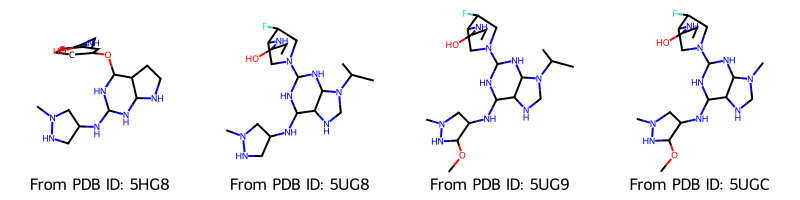

In [14]:
Draw.MolsToGridImage(
    molecules,
    molsPerRow=4,
    legends=[f"From PDB ID: {pdb_id}" for pdb_id in pdb_ids],
)

In [15]:
# Load SMILES for PDB ligand structures
ligands = pd.read_csv(DATA_DIR / "T008" / "PDB_top_ligands.csv")

# Get SMILES in the same order as in pdb_ids
ligand_smiles = [
    ligands[ligands["@structureId"] == pdb_id]["smiles"].values[0] for pdb_id in pdb_ids
]

# Generate RDKit Mol object from SMILES
reference_molecules = [Chem.MolFromSmiles(smiles) for smiles in ligand_smiles]

# Assign bond orders to molecules based on SMILES patterns of reference molecules
molecules = [
    AllChem.AssignBondOrdersFromTemplate(reference_molecule, molecule)
    for reference_molecule, molecule in zip(reference_molecules, molecules)
]

[00:33:48] WARNING: More than one matching pattern found - picking one

[00:33:48] WARNING: More than one matching pattern found - picking one



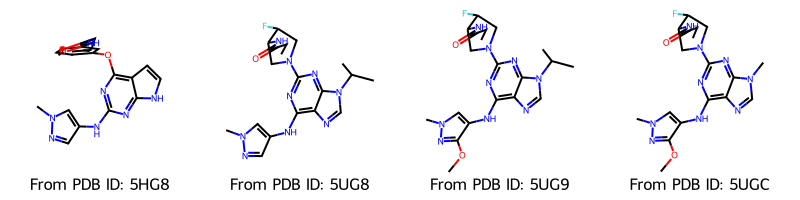

In [16]:
Draw.MolsToGridImage(
    molecules,
    molsPerRow=4,
    legends=[f"From PDB ID: {pdb_id}" for pdb_id in pdb_ids],
)

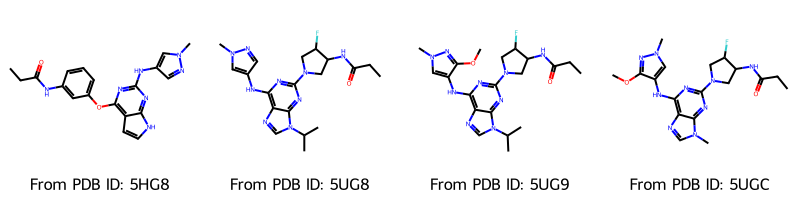

In [17]:
molecules_2d = []
for molecule in molecules:
    tmp = Chem.Mol(molecule)
    AllChem.Compute2DCoords(tmp)
    molecules_2d.append(tmp)
Draw.MolsToGridImage(
    molecules_2d,
    molsPerRow=4,
    legends=[f"From PDB ID: {pdb_id}" for pdb_id in pdb_ids],
)

In [19]:
import nglview as nv

In [20]:
def show_ligands(molecules):
    """Generate a view of the ligand molecules.

    Parameters
    -----------
    molecules: list of rdkit.Chem.rdchem.Mol

    Returns
    ----------
    nglview.widget.NGLWidget
    """
    view = nv.NGLWidget()
    for molecule in molecules:
        component = view.add_component(molecule)
        time.sleep(0.1)
        component.clear()
        component.add_ball_and_stick(multipleBond=True)
    return view

view = show_ligands(molecules)
view

NGLWidget()

In [21]:
view.render_image(trim=True, factor=2, transparent=True);
view._display_image()

### Extract Pharmacophore Features


In [22]:
feature_factory = AllChem.BuildFeatureFactory(str(Path(RDConfig.RDDataDir) / "BaseFeatures.fdef"))

In [23]:
list(feature_factory.GetFeatureDefs().keys())

['Donor.SingleAtomDonor',
 'Acceptor.SingleAtomAcceptor',
 'NegIonizable.AcidicGroup',
 'PosIonizable.BasicGroup',
 'PosIonizable.PosN',
 'PosIonizable.Imidazole',
 'PosIonizable.Guanidine',
 'ZnBinder.ZnBinder1',
 'ZnBinder.ZnBinder2',
 'ZnBinder.ZnBinder3',
 'ZnBinder.ZnBinder4',
 'ZnBinder.ZnBinder5',
 'ZnBinder.ZnBinder6',
 'Aromatic.Arom4',
 'Aromatic.Arom5',
 'Aromatic.Arom6',
 'Aromatic.Arom7',
 'Aromatic.Arom8',
 'Hydrophobe.ThreeWayAttach',
 'Hydrophobe.ChainTwoWayAttach',
 'LumpedHydrophobe.Nitro2',
 'LumpedHydrophobe.RH6_6',
 'LumpedHydrophobe.RH5_5',
 'LumpedHydrophobe.RH4_4',
 'LumpedHydrophobe.RH3_3',
 'LumpedHydrophobe.tButyl',
 'LumpedHydrophobe.iPropyl']

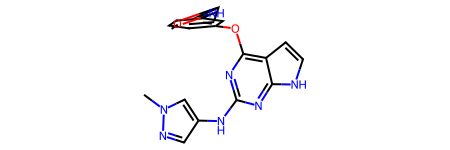

In [24]:
example_mol = molecules[0]
example_mol

In [25]:
# NBVAL_CHECK_OUTPUT
features = feature_factory.GetFeaturesForMol(example_mol)
print(f"Number of features found: {len(features)}")

Number of features found: 16


In [26]:
features[0].GetFamily()

'Donor'

In [27]:
# Get. frequency of each feature family in the example molecule
feature_frequency = collections.Counter(sorted([feature.GetFamily() for feature in features]))
feature_frequency

Counter({'Acceptor': 5,
         'Aromatic': 4,
         'Donor': 4,
         'Hydrophobe': 2,
         'LumpedHydrophobe': 1})

In [28]:
molecule_feature_frequencies = []
for molecule in molecules:
    features = [feature.GetFamily() for feature in feature_factory.GetFeaturesForMol(molecule)]
    feature_frequency = collections.Counter(features)
    molecule_feature_frequencies.append(feature_frequency)

feature_frequencies_df = (
    pd.DataFrame(
        molecule_feature_frequencies,
        index=[f"Mol{i}" for i, _ in enumerate(molecules, 1)],
    )
    .fillna(0)
    .astype(int)
)
feature_frequencies_df.transpose()

,Mol1,Mol2,Mol3,Mol4
Donor,4,2,2,2
Acceptor,5,6,7,7
Aromatic,4,3,3,3
Hydrophobe,2,1,1,1
LumpedHydrophobe,1,1,1,0
PosIonizable,0,1,1,1


In [29]:
# Concentrate on HBA, HBD, and Hydrophobics features
acceptors = []
donors = []
hydrophobics = []

for molecule in molecules:
    acceptors.append(feature_factory.GetFeaturesForMol(molecule, includeOnly="Acceptor"))
    donors.append(feature_factory.GetFeaturesForMol(molecule, includeOnly="Donor"))
    hydrophobics.append(feature_factory.GetFeaturesForMol(molecule, includeOnly="Hydrophobe"))

features = {
    "donors": donors,
    "acceptors": acceptors,
    "hydrophobics": hydrophobics,
}

In [30]:
feature_colors = {
    "donors": (0, 0.9, 0),  # Green
    "acceptors": (0.9, 0, 0),  # Red
    "hydrophobics": (1, 0.9, 0),  # Yellow
}

In [31]:
def visualize_features(
    molecules,
    features,
    feature_type="features",
    color="yellow",
    sphere_radius=0.5,
):
    """Generate a view of the molecules highlighting the specified feature type.

    Parameters
    -----------
    molecules: list of rdkit.Chem.rdchem.Mol
        molecules to be visualized
    features: list of tuples of rdkit.Chem.rdMolChemicalFeatures.MolChemicalFeature
        extracted features from molecules chosen to be highlighted
    feature_type: string, optional
        name of the feature to be highlighted
    color: string, optional
        color used to display the highlighted features
    sphere_radius: float, optional
        display size of the highlighted features

    Returns
    ----------
    nglview.widget.NGLWidget
    """
    print(f"Number of {feature_type} in all ligands: {sum([len(i) for i in features])}")
    view = show_ligands(molecules)
    for i, feature_set in enumerate(features, 1):
        for feature in feature_set:
            loc = list(feature.GetPos())
            label = f"{feature_type}_{i}"
            view.shape.add_sphere(loc, color, sphere_radius, label)
    return view

In [32]:
feature_type = "donors"
view = visualize_features(
    molecules,
    features[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view

Number of donors in all ligands: 10


NGLWidget()

In [33]:
view.render_image(trim=True, factor=2, transparent=True);

In [34]:
view._display_image()

In [35]:
# HBA's
feature_type = "acceptors"
view = visualize_features(
    molecules,
    features[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view

Number of acceptors in all ligands: 25


NGLWidget()

In [36]:
feature_type = "hydrophobics"
view = visualize_features(
    molecules,
    features[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view

Number of hydrophobics in all ligands: 5


NGLWidget()

In [37]:
features_coord = {
    "donors": [list(item.GetPos()) for sublist in features["donors"] for item in sublist],
    "acceptors": [list(item.GetPos()) for sublist in features["acceptors"] for item in sublist],
    "hydrophobics": [
        list(item.GetPos()) for sublist in features["hydrophobics"] for item in sublist
    ],
}

> NOTE: algorithm - clustering, k-means, process
Generate ensemble pharmacophores
To generate ensemble pharmacophores we use k-means clustering (cluster features per feature type).

Set static parameters for k-means clustering:
kq: number of clusters k per feature type depending on the number of feature types.

k = number_of_features / kq

kq should be selected so that k (feature clusters) is for all clusters >=1 and <= 4-5 clusters

Set static params for cluster selection:
min_cluster_size: We only want to retain clusters that potentially contain features from most molecules in our ligand ensemble. Therefore, we set this variable to 75% of the number of molecules in our ligand ensemble.

top_cluster_number: With this parameter, we select only the largest clusters.

In [47]:
kq = 7
min_cluster_size = int(len(molecules) * 0.75)
top_cluster_number = 4

def clustering(feature_coord, kq):
    """
    Compute the k-means clustering of input feature coordinates.

    Parameters
    -----------
    feature_coord: list
        feature coordinates extracted from the features of a set of molecules
    kq: int
        Quotient used when calculating number of features k

    Returns
    ----------
    sklearn.cluster._kmeans.KMeans
    """
    # Define parameter k as feature number divided by "k quotient"
    k = math.ceil(len(feature_coord) / kq)
    # Tailor-made adaption of k for hydrophobics in for the example in this talktorial
    k = 2 if k == 1 else k
    print(f"Clustering: \nVariable k in k-means: {k} of {len(feature_coord)} points\n")

    # Initialize k-means and compute clustering
    k_means = cluster.KMeans(n_clusters=k, n_init=10)
    k_means.fit(feature_coord)

    return k_means

# Helper function that sorts the clusters by size and outputs a list of indices of the largest clusters.
def get_clusters(k_means, min_cluster_size, top_cluster_number):
    """
    Select clusters from a k-means clustering and returns the indices of the selected clusters.
    The selection is based on cluster size. The largest clusters are chosen.

    Parameters
    -----------
    k_means: sklearn.cluster._kmeans.KMeans
        k-means clustering of feature coordinates
    min_cluster_size: int
        minimum size needed for a cluster to be viable for selection
    top_cluster_number: int
        number of clusters to be selected

    Returns
    ----------
    list of int
        indices of selected clusters
    """

    # Sort clusters by size and only show largest
    feature_labels = k_means.labels_

    feature_labels_count = Counter(feature_labels)

    feature_labels_count = sorted(
        feature_labels_count.items(), key=operator.itemgetter(1), reverse=True
    )
    print(f"Clusters sorted by size: \n{feature_labels_count}\n")

    # Get number of the largest clusters, which are larger then the threshold (selected clusters)
    cluster_indices_sel = []

    for cluster_index, cluster_size in feature_labels_count:
        if cluster_size >= min_cluster_size and top_cluster_number > 0:
            cluster_indices_sel.append(int(cluster_index))
            top_cluster_number -= 1

    print(f"Cluster indices of selected clusters: \n{cluster_indices_sel}\n")

    return cluster_indices_sel

In [39]:
k_means = {
    "donors": clustering(features_coord["donors"], kq),
    "acceptors": clustering(features_coord["acceptors"], kq),
    "hydrophobics": clustering(features_coord["hydrophobics"], kq),
}

Clustering: 
Variable k in k-means: 2 of 10 points

Clustering: 
Variable k in k-means: 4 of 25 points

Clustering: 
Variable k in k-means: 2 of 5 points



In [48]:
print("Hydrogen bond donors\n")
cluster_indices_sel_donors = get_clusters(k_means["donors"], min_cluster_size, top_cluster_number)

Hydrogen bond donors

Clusters sorted by size: 
[(np.int32(1), 6), (np.int32(0), 4)]

Cluster indices of selected clusters: 
[1, 0]



In [49]:
print("Hydrogen bond acceptors\n")
cluster_indices_sel_acceptors = get_clusters(
    k_means["acceptors"], min_cluster_size, top_cluster_number
)

Hydrogen bond acceptors

Clusters sorted by size: 
[(np.int32(0), 12), (np.int32(1), 6), (np.int32(2), 4), (np.int32(3), 3)]

Cluster indices of selected clusters: 
[0, 1, 2, 3]



In [50]:
print("Hydrophobic contacts\n")
cluster_indices_sel_hydrophobic = get_clusters(
    k_means["hydrophobics"], min_cluster_size, top_cluster_number
)

Hydrophobic contacts

Clusters sorted by size: 
[(np.int32(0), 4), (np.int32(1), 1)]

Cluster indices of selected clusters: 
[0]



In [43]:
def get_selected_cluster_center_coords(k_means, cluster_indices_sel):
    """Retrieve cluster center coordinates for selected clusters.
    The selected clusters are defined by their indices.

    Parameters
    -----------
    k_means: sklearn.cluster._kmeans.KMeans
        k-means clustering of feature coordinates
    cluster_indices_sel: list of int
        indices of the chosen clusters

    Returns
    ----------
    two-dimensional list of floats
        cluster center coordinates
    """
    cluster_centers = k_means.cluster_centers_

    # Cast to list and then to pandas Series (for element selection by indices)
    cluster_centers = pd.Series(cluster_centers.tolist())

    # Select cluster centers by indices of selected clusters
    cluster_centers_sel = cluster_centers[cluster_indices_sel]

    return list(cluster_centers_sel)

In [52]:
cluster_centers_sel = {
    "donors": get_selected_cluster_center_coords(k_means["donors"], cluster_indices_sel_donors),
    "acceptors": get_selected_cluster_center_coords(
        k_means["acceptors"], cluster_indices_sel_acceptors
    ),
    "hydrophobics": get_selected_cluster_center_coords(
        k_means["hydrophobics"], cluster_indices_sel_hydrophobic
    ),
}


In [53]:
cluster_centers_sel["acceptors"]

[[-12.567833333333333, 14.66725, -28.191333333333333],
 [-16.466333333333335, 10.624666666666666, -26.801333333333332],
 [-16.076, 17.244500000000002, -22.4005],
 [-15.465, 19.241, -27.253]]

In [54]:
def visualize_clusters(
    molecules,
    features,
    clusters,
    feature_type="features",
    color="yellow",
    feature_radius=0.5,
    cluster_radius=1,
):
    """Visualize the cluster centers.

    Parameters
    -----------
     molecules: list of rdkit.Chem.rdchem.Mol
        molecules to be visualized
    features: list of tuples of rdkit.Chem.rdMolChemicalFeatures.MolChemicalFeature
        extracted features from molecules chosen to be highlighted
    clusters: Two-dimensional list of floats
        cluster center coordinates
    feature_type: string, optional
        feature type being visualized
    color: string, optional
        color used for rendering the features and cluster centers
    feature_radius: float, optional
        rendering size of the features
    cluster_radius: float, optional
        rendering size of the cluster centers

    Returns
    ----------
    nglview.widget.NGLWidget
    """
    view = visualize_features(
        molecules,
        features,
        feature_type,
        color=color,
        sphere_radius=feature_radius,
    )
    for i, center in enumerate(clusters, 1):
        view.shape.add_sphere(list(center), color, cluster_radius, f"cluster_{feature_type}_{i}")
    return view

In [61]:
import nglview as nv
view = nv.show_pdbid("1tsu")

In [62]:
feature_type = "donors"
view = visualize_clusters(
    molecules,
    features[feature_type],
    cluster_centers_sel[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view

Number of donors in all ligands: 10


NGLWidget()

In [63]:
view.render_image(trim=True, factor=2, transparent=True)

Image(value=b'', width='99%')

In [64]:
view._display_image()

In [67]:
feature_type = "acceptors"
view = visualize_clusters(
    molecules,
    features[feature_type],
    cluster_centers_sel[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view

Number of acceptors in all ligands: 25


NGLWidget()

In [68]:
feature_type = "hydrophobics"
view = visualize_clusters(
    molecules,
    features[feature_type],
    cluster_centers_sel[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view

Number of hydrophobics in all ligands: 5


NGLWidget()

In [70]:
view = show_ligands(molecules)
# Load clusters
for feature_type in cluster_centers_sel.keys():
    centers = cluster_centers_sel[feature_type]
    for i, loc in enumerate(centers):
        sphere_radius = 1
        feature_color = feature_colors[feature_type]
        label = f"{feature_type}_c{i}"
        view.shape.add_sphere(loc, feature_color, sphere_radius, label)
view


NGLWidget()

> NOTE:
Quiz¶
Explain the terms pharmacophoric features and pharmacophore.

Explain the difference between structure- and ligand-based pharmacophore modeling.

Explain how we derived an ensemble pharmacophore.